In [2]:
import os
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [3]:
zip_path = r"C:\Users\sinha\Desktop\ISA Project\CMAPSSData.zip"
extract_path = "CMAPSSData"

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

print("Dataset extracted!")

Dataset extracted!


In [4]:
index_cols = ['unit_nr', 'time_cycles']
setting_cols = ['setting_1', 'setting_2', 'setting_3']
sensor_cols = [f's_{i}' for i in range(1, 22)]

columns = index_cols + setting_cols + sensor_cols

In [5]:
def load_dataset(dataset_id):
    train_path = f"{extract_path}/train_{dataset_id}.txt"
    test_path = f"{extract_path}/test_{dataset_id}.txt"
    rul_path = f"{extract_path}/RUL_{dataset_id}.txt"

    train = pd.read_csv(train_path, sep=r'\s+', header=None)
    train.columns = columns

    test = pd.read_csv(test_path, sep=r'\s+', header=None)
    test.columns = columns

    rul = pd.read_csv(rul_path, sep=r'\s+', header=None)
    rul.columns = ['RUL']

    return train, test, rul

In [6]:
train_df, test_df, rul_df = load_dataset("FD001")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
train_df.head()

Train shape: (20631, 26)
Test shape: (13096, 26)


,unit_nr,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_12,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [7]:
max_cycles = train_df.groupby('unit_nr')['time_cycles'].max().reset_index()
max_cycles.columns = ['unit_nr', 'max_cycle']

train_df = train_df.merge(max_cycles, on='unit_nr')
train_df['RUL'] = train_df['max_cycle'] - train_df['time_cycles']

train_df.drop(columns=['max_cycle'], inplace=True)

train_df.head()

,unit_nr,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


In [8]:
train_df.info()
train_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 27 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   unit_nr      20631 non-null  int64  
 1   time_cycles  20631 non-null  int64  
 2   setting_1    20631 non-null  float64
 3   setting_2    20631 non-null  float64
 4   setting_3    20631 non-null  float64
 5   s_1          20631 non-null  float64
 6   s_2          20631 non-null  float64
 7   s_3          20631 non-null  float64
 8   s_4          20631 non-null  float64
 9   s_5          20631 non-null  float64
 10  s_6          20631 non-null  float64
 11  s_7          20631 non-null  float64
 12  s_8          20631 non-null  float64
 13  s_9          20631 non-null  float64
 14  s_10         20631 non-null  float64
 15  s_11         20631 non-null  float64
 16  s_12         20631 non-null  float64
 17  s_13         20631 non-null  float64
 18  s_14         20631 non-null  float64
 19  s_15

,unit_nr,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21,RUL
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,20631.00,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,518.67,642.680934,1590.523119,1408.933782,1.462000e+01,...,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705,107.807862
std,29.227633,68.880990,0.002187,0.000293,0.0,0.00,0.500053,6.131150,9.000605,5.329200e-15,...,0.071919,19.076176,0.037505,3.469531e-18,1.548763,0.0,0.0,0.180746,0.108251,68.880990
min,1.000000,1.000000,-0.008700,-0.000600,100.0,518.67,641.210000,1571.040000,1382.250000,1.462000e+01,...,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200,0.000000
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,518.67,642.325000,1586.260000,1402.360000,1.462000e+01,...,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800,51.000000
50%,52.000000,104.000000,0.000000,0.000000,100.0,518.67,642.640000,1590.100000,1408.040000,1.462000e+01,...,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900,103.000000
75%,77.000000,156.000000,0.001500,0.000300,100.0,518.67,643.000000,1594.380000,1414.555000,1.462000e+01,...,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800,155.000000
max,100.000000,362.000000,0.008700,0.000600,100.0,518.67,644.530000,1616.910000,1441.490000,1.462000e+01,...,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400,361.000000


In [9]:
train_df.isnull().sum()

unit_nr        0
time_cycles    0
setting_1      0
setting_2      0
setting_3      0
s_1            0
s_2            0
s_3            0
s_4            0
s_5            0
s_6            0
s_7            0
s_8            0
s_9            0
s_10           0
s_11           0
s_12           0
s_13           0
s_14           0
s_15           0
s_16           0
s_17           0
s_18           0
s_19           0
s_20           0
s_21           0
RUL            0
dtype: int64

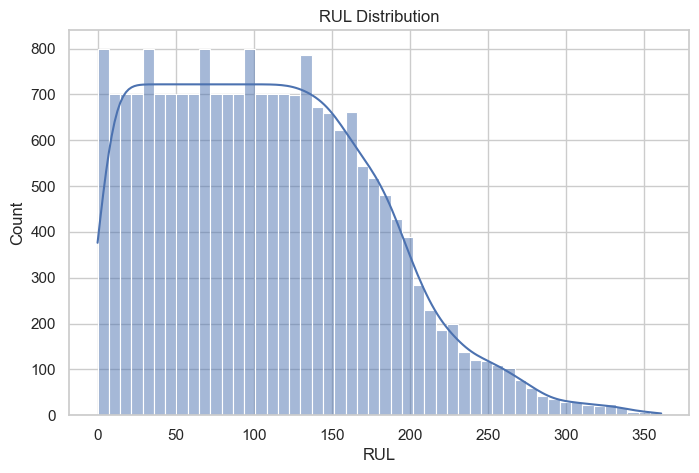

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(train_df['RUL'], bins=50, kde=True)
plt.title("RUL Distribution")
plt.show()

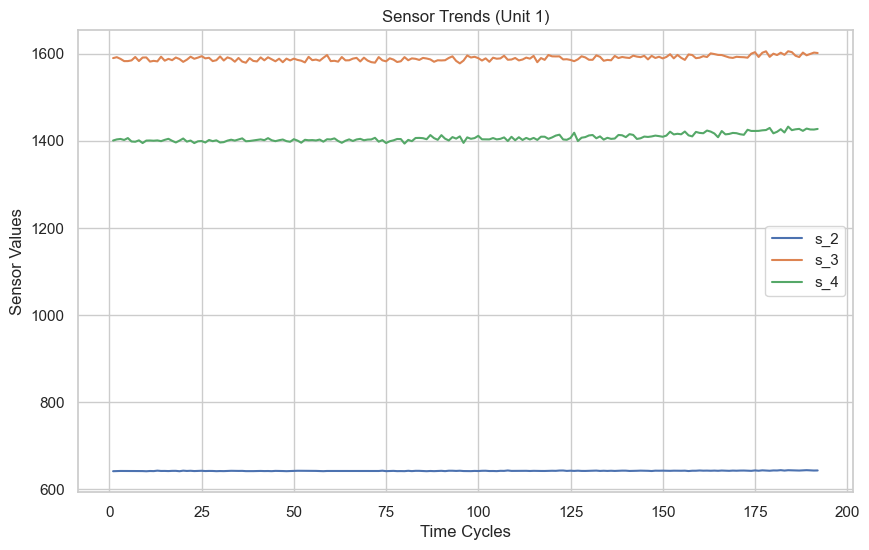

In [11]:
unit_sample = train_df[train_df['unit_nr'] == 1]

plt.figure(figsize=(10,6))
for sensor in ['s_2', 's_3', 's_4']:
    plt.plot(unit_sample['time_cycles'], unit_sample[sensor], label=sensor)

plt.legend()
plt.title("Sensor Trends (Unit 1)")
plt.xlabel("Time Cycles")
plt.ylabel("Sensor Values")
plt.show()

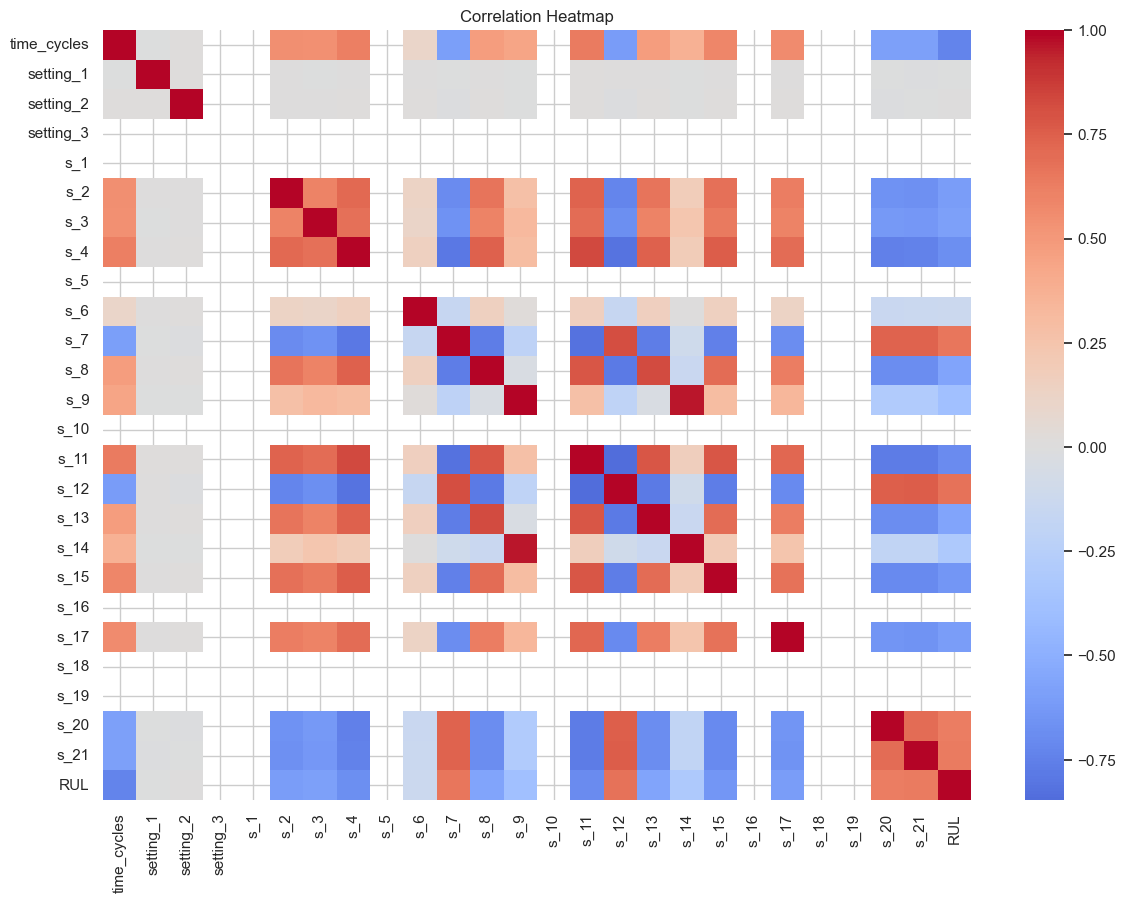

In [12]:
plt.figure(figsize=(14,10))
corr = train_df.drop(columns=['unit_nr']).corr()

sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap")
plt.show()

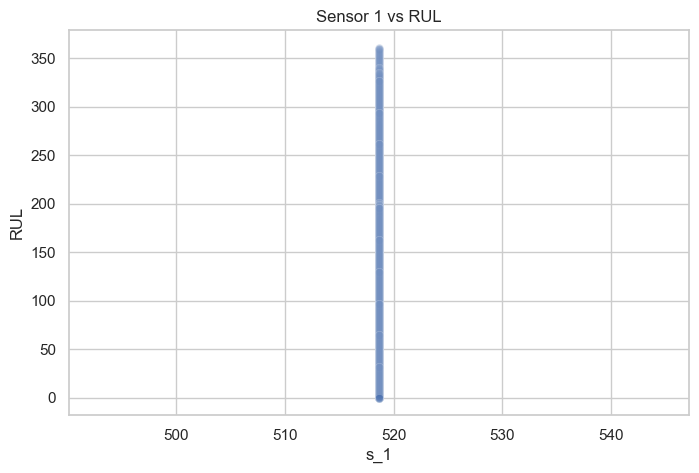

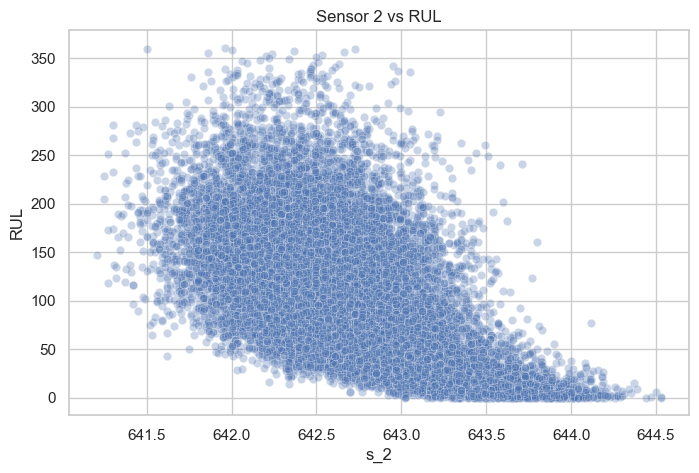

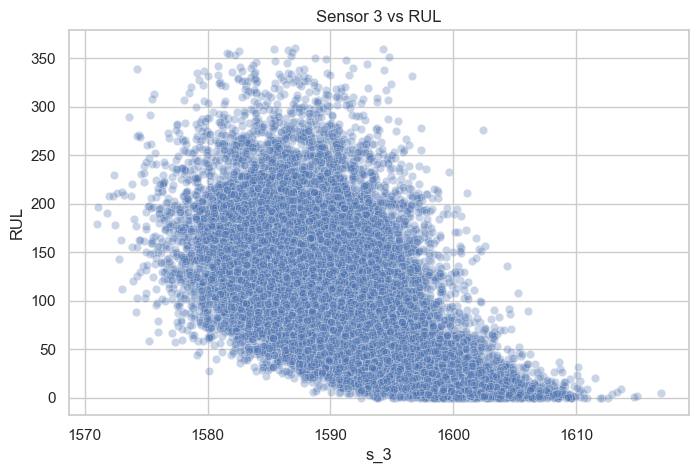

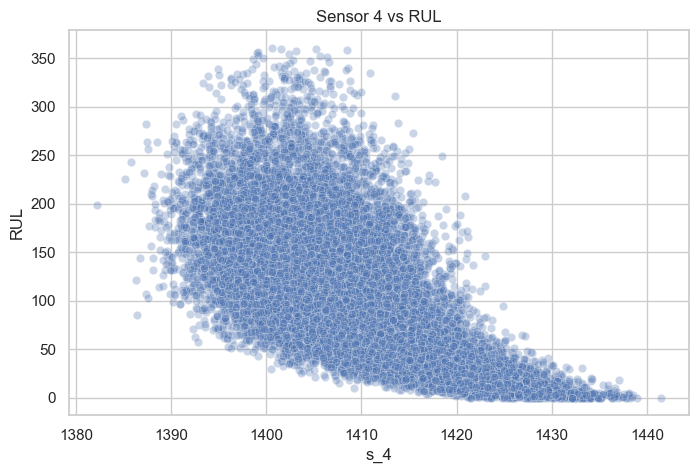

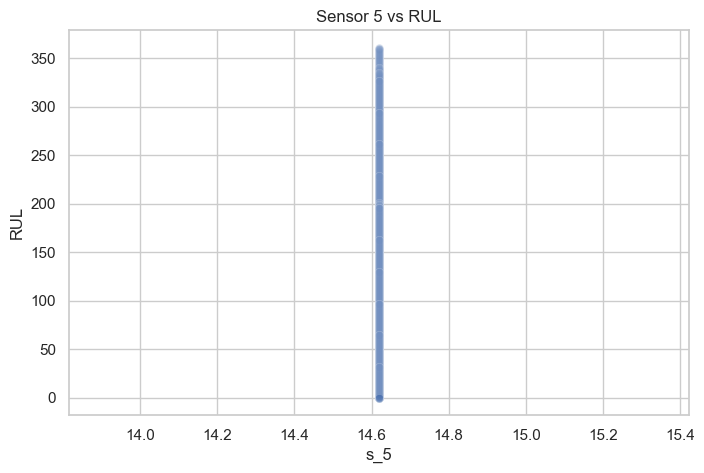

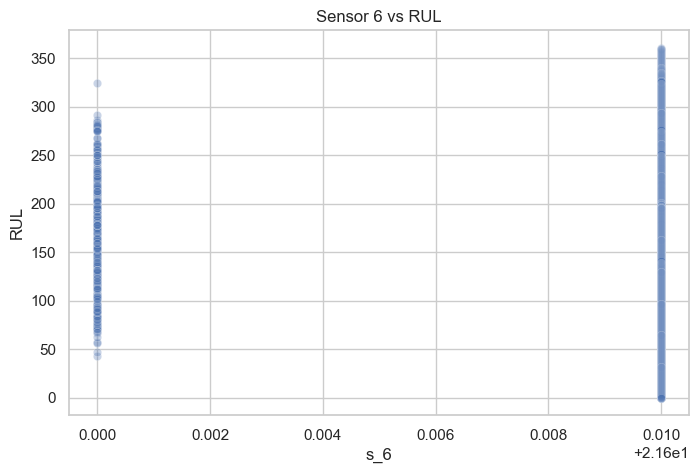

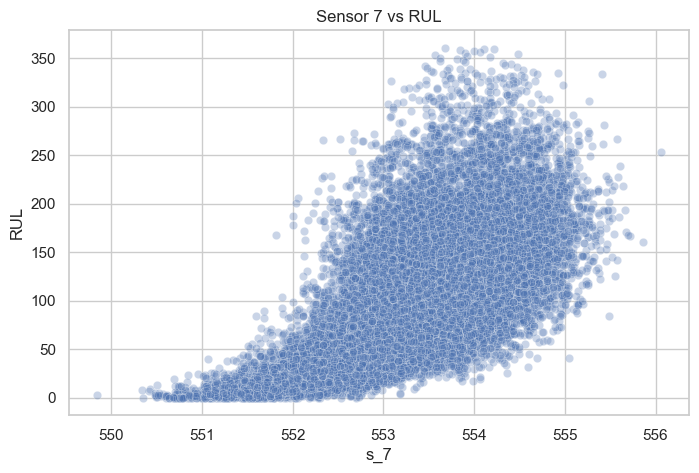

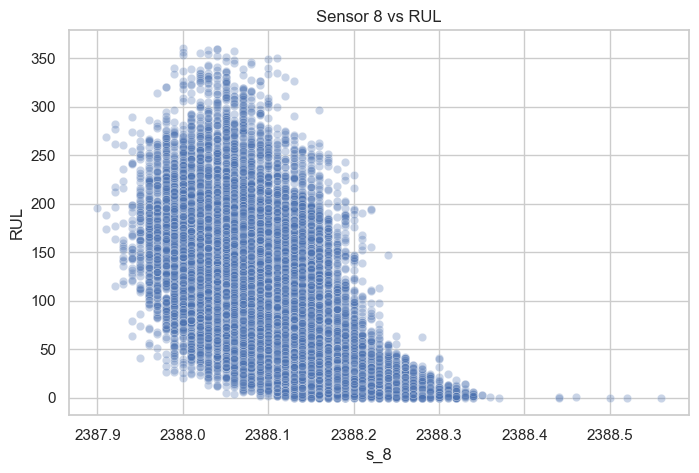

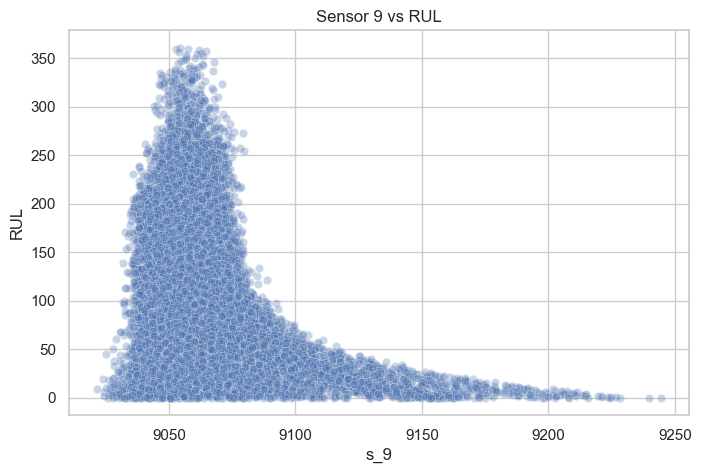

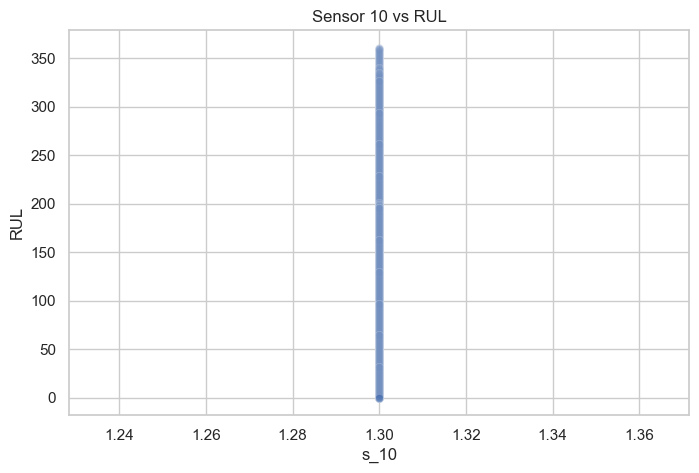

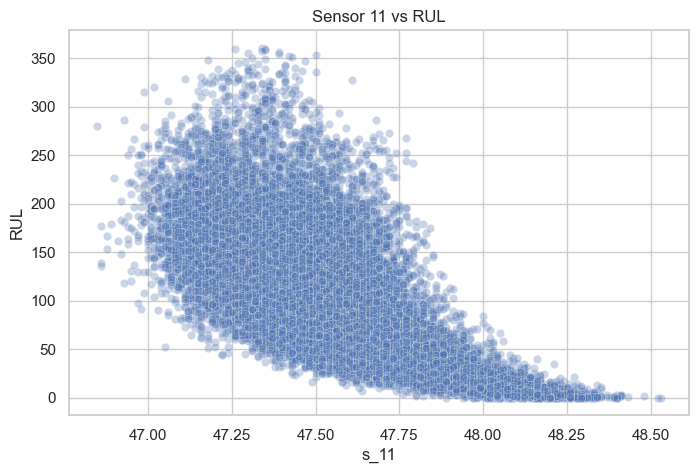

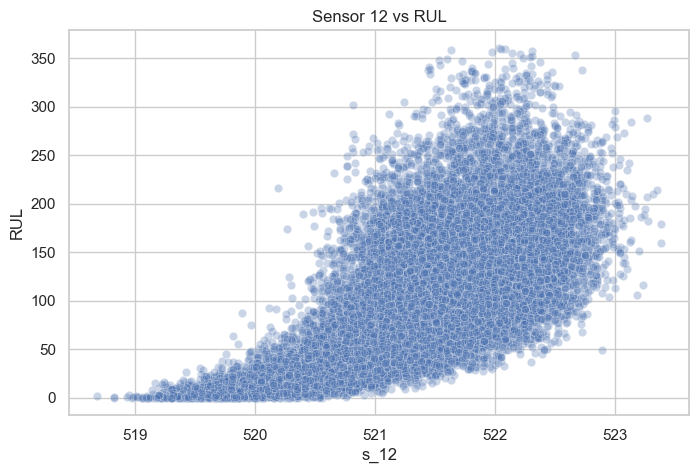

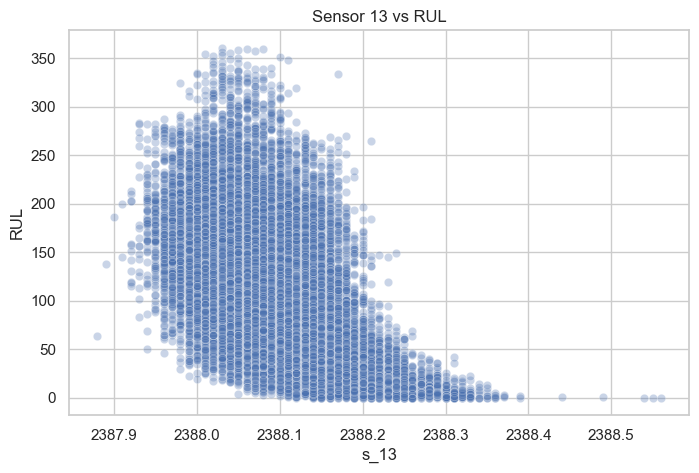

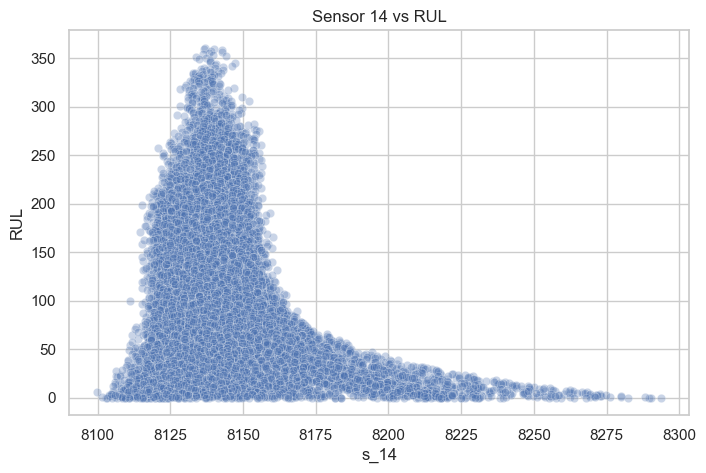

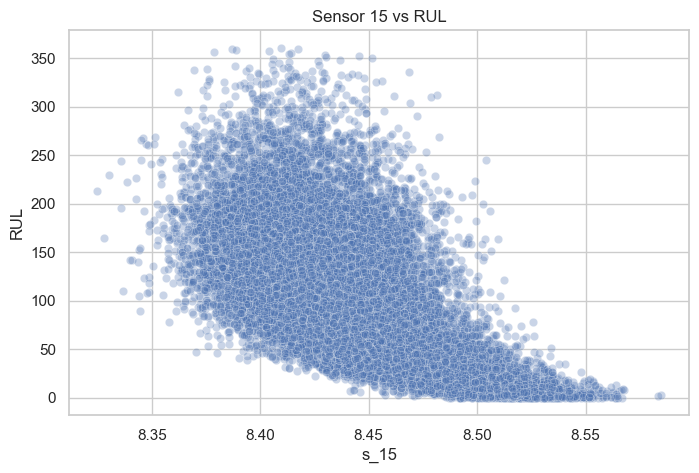

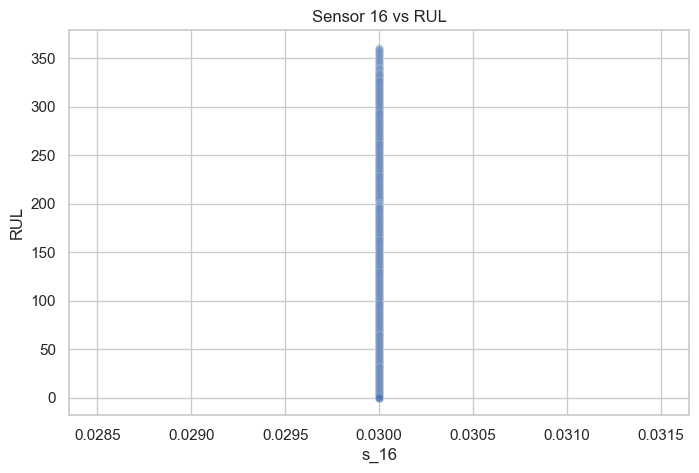

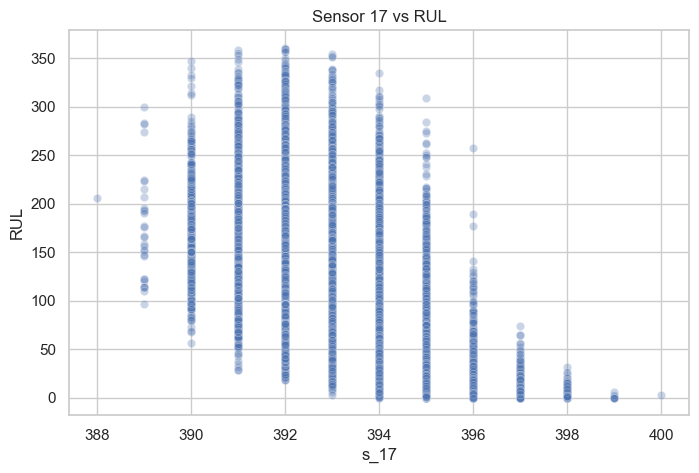

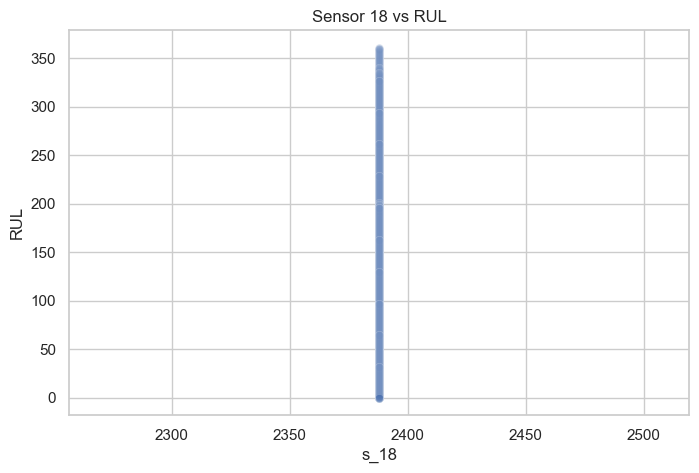

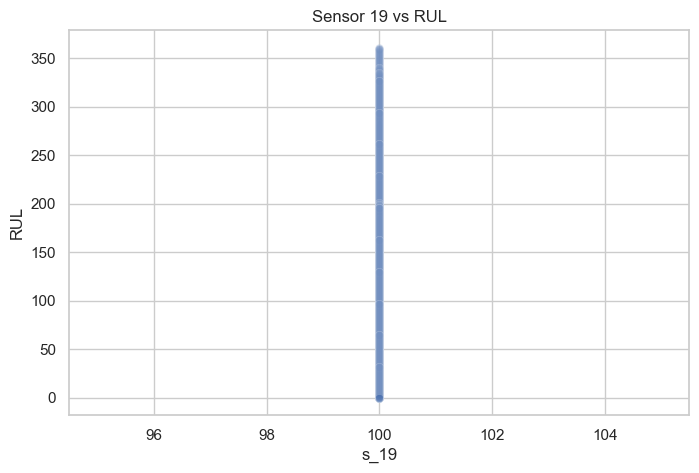

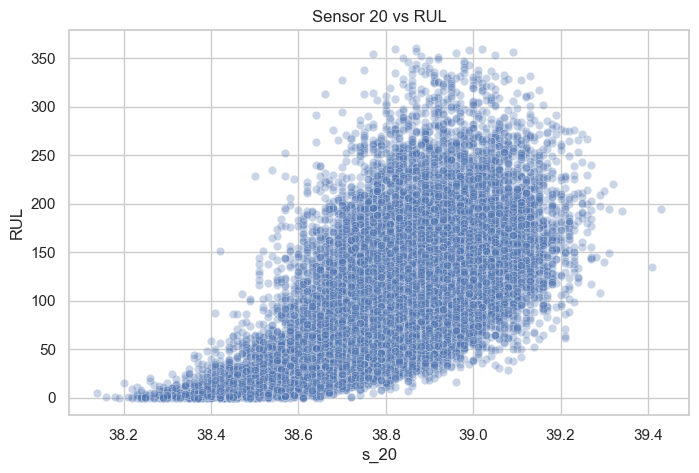

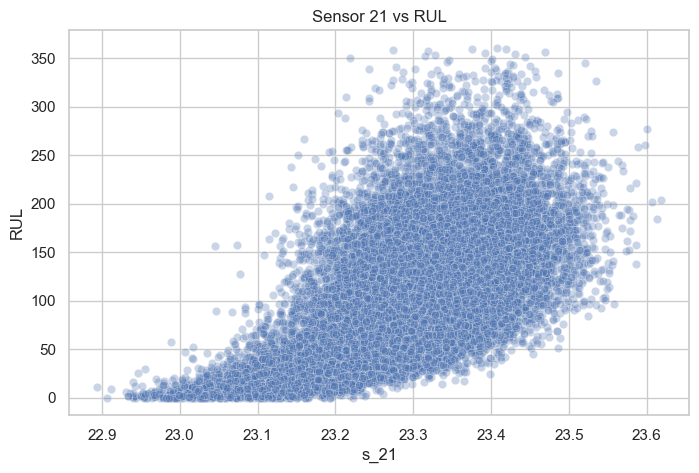

In [13]:
for i in range(1, 22):
    plt.figure(figsize=(8,5))
    sns.scatterplot(x=train_df[f's_{i}'], y=train_df['RUL'], alpha=0.3)
    plt.title(f"Sensor {i} vs RUL")
    plt.show() 

In [14]:
low_variance = train_df.var()[train_df.var() < 1e-3]
print("Low variance sensors:\n", low_variance)

Low variance sensors:
 setting_1    4.784340e-06
setting_2    8.588541e-08
setting_3    0.000000e+00
s_1          0.000000e+00
s_5          2.840037e-29
s_6          1.929279e-06
s_10         0.000000e+00
s_16         1.203765e-35
s_18         0.000000e+00
s_19         0.000000e+00
dtype: float64


In [15]:
# datasets = ["FD001", "FD002", "FD003", "FD004"]

# for d in datasets:
#     train_df, _, _ = load_dataset(d)

#     max_cycles = train_df.groupby('unit_nr')['time_cycles'].max().reset_index()
#     max_cycles.rename(columns={'time_cycles': 'max_cycle'}, inplace=True)

#     train_df = train_df.merge(max_cycles, on='unit_nr')
#     train_df['RUL'] = train_df['max_cycle'] - train_df['time_cycles']

#     print(f"\nDataset: {d}")
#     print("Shape:", train_df.shape)
#     print("RUL mean:", train_df['RUL'].mean())